# Question 1 : Linear Regression

### Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
np.random.seed(42)
DATA_PATH = '/kaggle/input/mobile-price-prediction/Cellphone.csv'

try:
    df = pd.read_csv(DATA_PATH)
except Exception as e:
    raise FileNotFoundError(f"Could not load data from {DATA_PATH}. Make sure the path is correct. Original error: {e}")


### EDA

Dataset shape: (161, 14)
['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']


,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB

Missing values per column:
Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core     

,count,mean,std,min,25%,50%,75%,max
Product_id,161.0,675.559006,410.851583,10.0,237.0,774.00,1026.000,1339.0
Price,161.0,2215.596273,768.187171,614.0,1734.0,2258.00,2744.000,4361.0
Sale,161.0,621.465839,1546.618517,10.0,37.0,106.00,382.000,9807.0
weight,161.0,170.426087,92.888612,66.0,134.1,153.00,170.000,753.0
resoloution,161.0,5.209938,1.509953,1.4,4.8,5.15,5.500,12.2
ppi,161.0,335.055901,134.826659,121.0,233.0,294.00,428.000,806.0
cpu core,161.0,4.857143,2.444016,0.0,4.0,4.00,8.000,8.0
cpu freq,161.0,1.502832,0.599783,0.0,1.2,1.40,1.875,2.7
internal mem,161.0,24.501714,28.804773,0.0,8.0,16.00,32.000,128.0
ram,161.0,2.204994,1.609831,0.0,1.0,2.00,3.000,6.0


Numeric columns: ['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


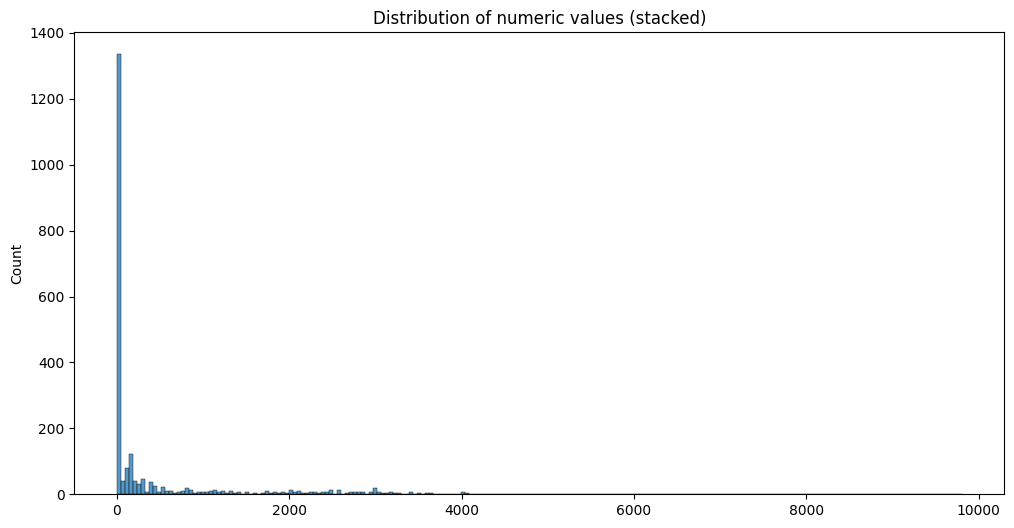

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

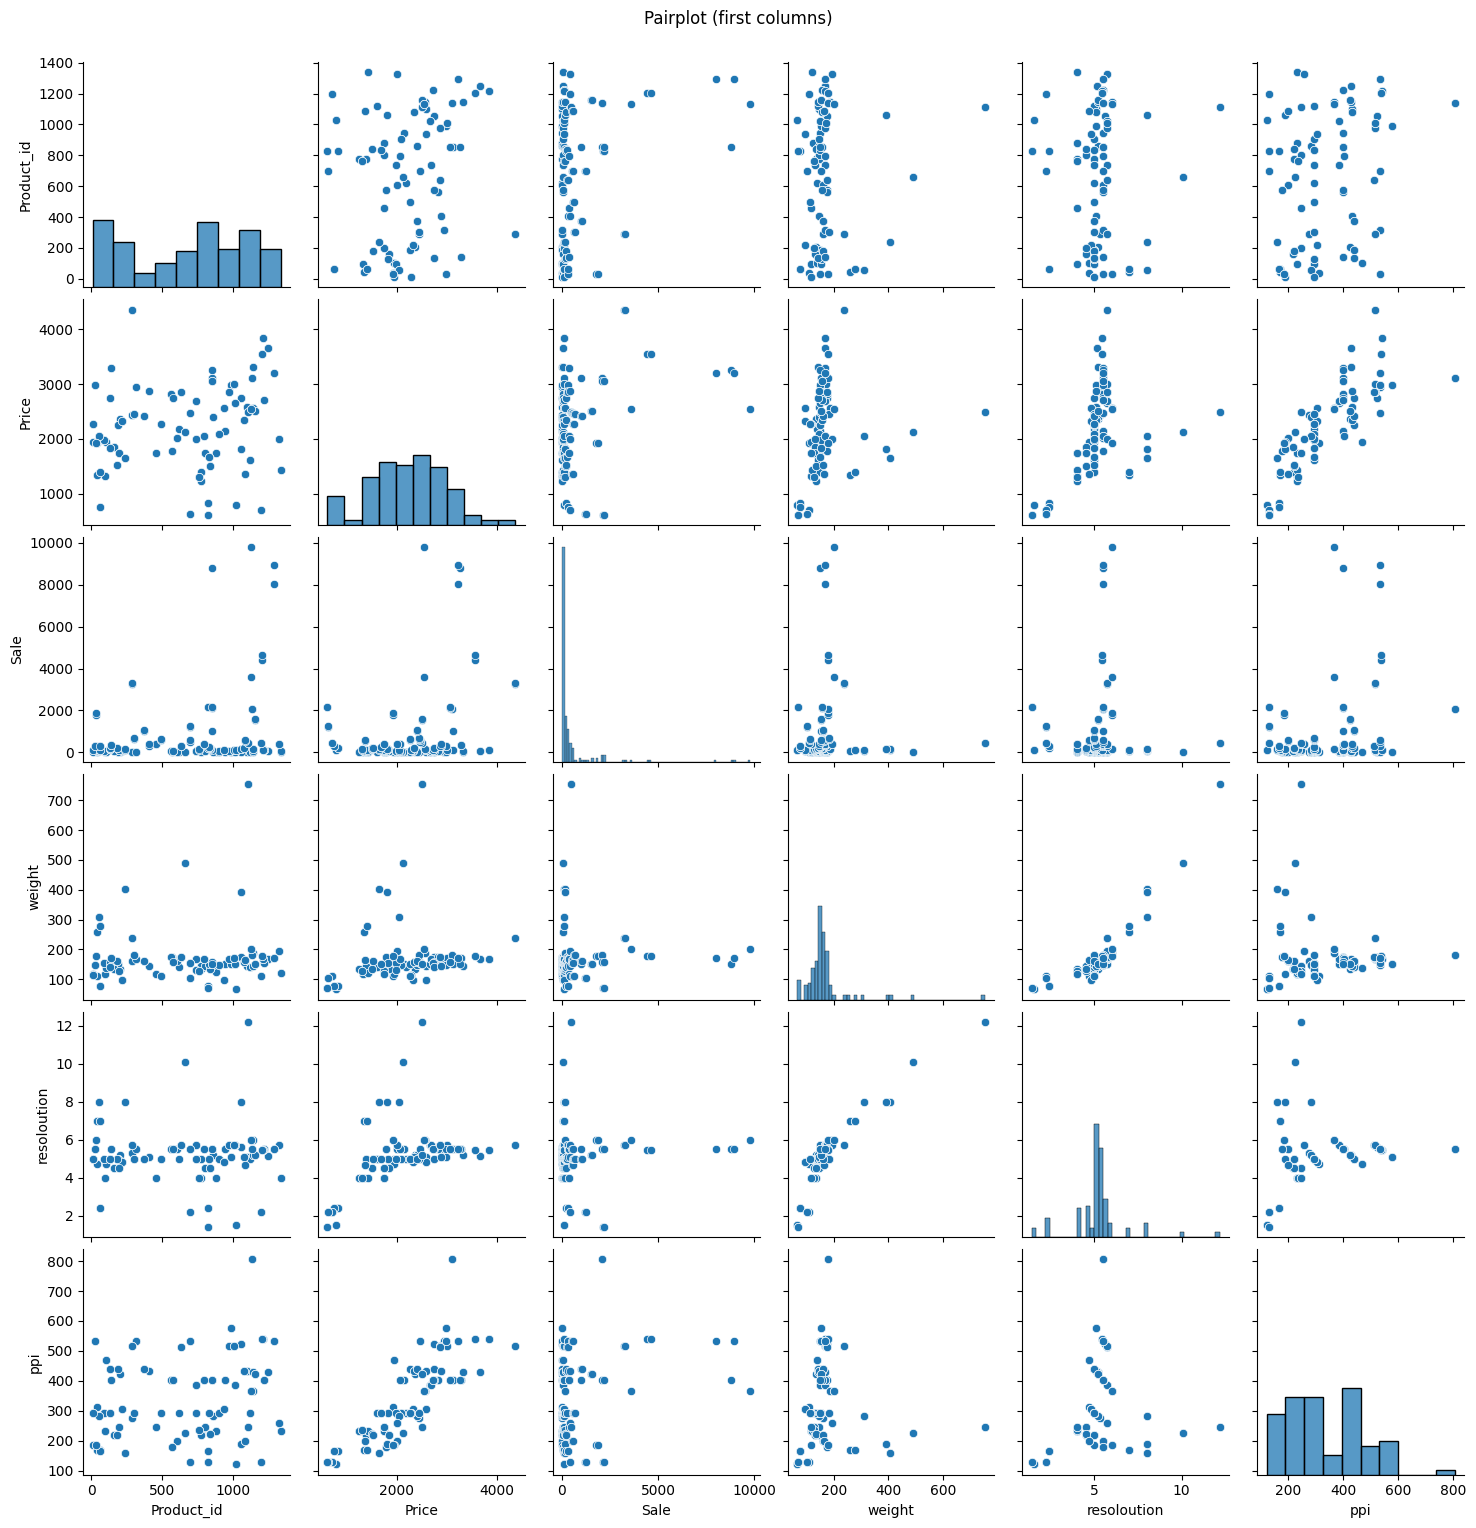

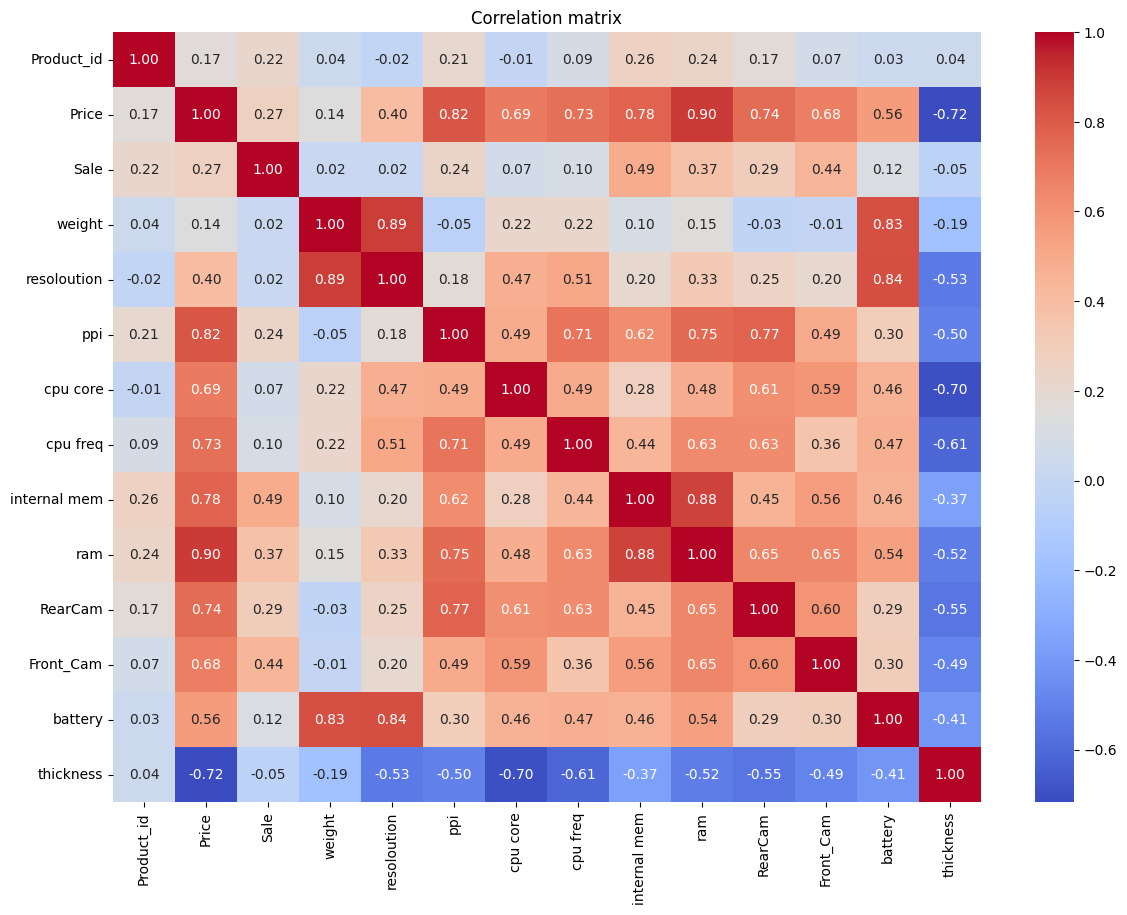


Outlier counts per numeric column:
Product_id       0
Price            2
Sale            24
weight          24
resoloution     26
ppi              2
cpu core         0
cpu freq        10
internal mem     8
ram              0
RearCam          0
Front_Cam        0
battery          6
thickness        8
dtype: int64

Target column: Price


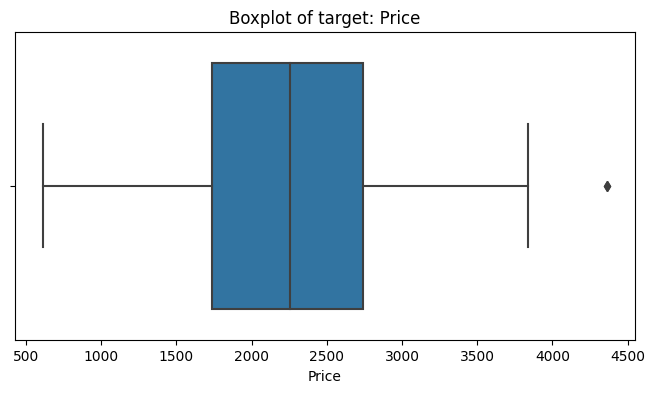

In [4]:
print('Dataset shape:', df.shape)
print(df.columns.tolist())
display(df.head())

# Data types and missing values
print('\nInfo:')
df.info()

print('\nMissing values per column:')
print(df.isna().sum())

# Basic statistics
display(df.describe().T)

# Histogram for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

plt.figure(figsize=(12, 6))
sns.histplot(df[numeric_cols].stack(), kde=False)
plt.title('Distribution of numeric values (stacked)')
plt.show()

# Pairplot for a subset (to avoid huge plots)
subset = numeric_cols[:6] if len(numeric_cols) > 6 else numeric_cols
sns.pairplot(df[subset])
plt.suptitle('Pairplot (first columns)', y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

print('\nOutlier counts per numeric column:')
print(pd.Series(outlier_summary))
TARGET = 'Price' if 'Price' in df.columns else numeric_cols[-1]
print('\nTarget column:', TARGET)

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[TARGET])
plt.title(f'Boxplot of target: {TARGET}')
plt.show()


### Preprocessing

In [5]:
# 5.1 Missing values
if df.isna().sum().sum() > 0:
    print('Total missing values found. Filling numeric with median and categorical with mode...')
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if df[col].dtype in [np.float64, np.int64]:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
else:
    print('No missing values found.')

# 5.2 Categorical encoding
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
if len(cat_cols) > 0:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print('Applied one-hot encoding to categorical columns.')

# 5.3 Final feature/target split
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataframe columns: {df.columns}")

X = df.drop(columns=[TARGET]).values
y = df[TARGET].values.reshape(-1, 1)

print('Feature matrix X shape:', X.shape)
print('Label vector y shape:', y.shape)

No missing values found.
Categorical columns: []
Feature matrix X shape: (161, 13)
Label vector y shape: (161, 1)


### Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('\nTrain shapes:', X_train.shape, y_train.shape)
print('Test shapes: ', X_test.shape, y_test.shape)

X_train_orig = X_train.copy()
X_test_orig = X_test.copy()


Train shapes: (128, 13) (128, 1)
Test shapes:  (33, 13) (33, 1)


In [7]:
def add_bias(X):
    """Add intercept term (column of ones) to design matrix."""
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])


def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


### Model Training and Evaluation

In [8]:
# theta = (X^T X)^(-1) X^T y
Xb = add_bias(X_train)
XtX = Xb.T @ Xb
XtX_inv = np.linalg.pinv(XtX)   # use pseudo-inverse for stability
theta_closed = XtX_inv @ Xb.T @ y_train
print('\nClosed-form theta shape:', theta_closed.shape)

# Prediction on test
Xb_test = add_bias(X_test)
y_pred_closed = Xb_test @ theta_closed
print('Closed-form test RMSE:', rmse(y_test, y_pred_closed))
print('Closed-form test R2:', r2_score(y_test, y_pred_closed))



Closed-form theta shape: (14, 1)
Closed-form test RMSE: 151.8625361672479
Closed-form test R2: 0.9593179111636351


In [10]:
print("NaNs in y_test:", np.isnan(y_test).sum())
print("NaNs in y_pred_gd:", np.isnan(y_pred_gd).sum())
print("Infs in y_pred_gd:", np.isinf(y_pred_gd).sum())


NaNs in y_test: 0
NaNs in y_pred_gd: 33
Infs in y_pred_gd: 0


In [13]:
def gradient_descent(X, y, lr=1e-3, n_iter=5000, tol=1e-6):
    Xb = add_bias(X)
    n, d = Xb.shape
    theta = np.zeros((d, 1))
    history = []
    for i in range(n_iter):
        preds = Xb @ theta
        error = preds - y
        grad = (2 / n) * (Xb.T @ error)
        theta = theta - lr * grad
        loss = np.mean(error ** 2)
        history.append(loss)
        if i > 0 and abs(history[-2] - history[-1]) < tol:
            break
    return theta, history


NaNs in y_pred_gd: 0

GD theta shape: (14, 1)


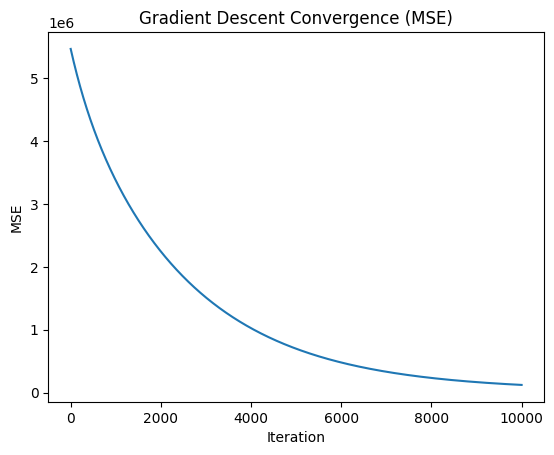

GD test RMSE: 287162.01687655406
GD test R2: -145463.13765059144


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
theta_gd, history = gradient_descent(X_train_scaled, y_train, lr=1e-4, n_iter=10000)

# Predict on scaled test data
y_pred_gd = add_bias(X_test_scaled) @ theta_gd

print("NaNs in y_pred_gd:", np.isnan(y_pred_gd).sum())
print('\nGD theta shape:', theta_gd.shape)

# Plot convergence
plt.figure()
plt.plot(history)
plt.title('Gradient Descent Convergence (MSE)')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.show()

# Predict
y_pred_gd = add_bias(X_test) @ theta_gd
print('GD test RMSE:', rmse(y_test, y_pred_gd))
print('GD test R2:', r2_score(y_test, y_pred_gd))

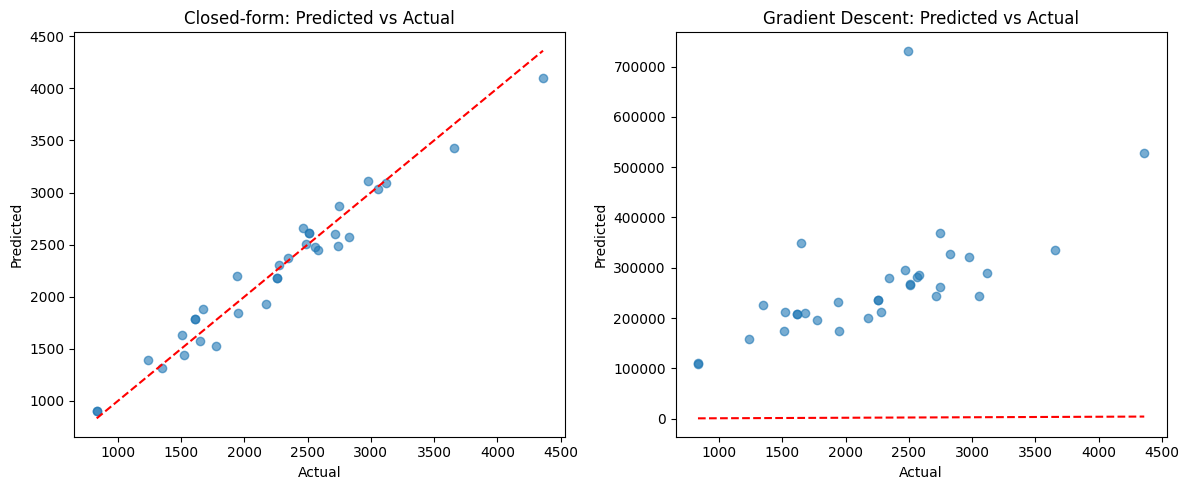


Closed-form MSE, RMSE, MAE, R2:
23062.229891148676 151.8625361672479 130.3153096104558 0.9593179111636351

GD MSE, RMSE, MAE, R2:
82462023936.6103 287162.01687655406 264011.0038318596 -145463.13765059144


In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_closed, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Closed-form: Predicted vs Actual')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_gd, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Gradient Descent: Predicted vs Actual')
plt.tight_layout()
plt.show()

# Metrics summary
print('\nClosed-form MSE, RMSE, MAE, R2:')
print(mse(y_test, y_pred_closed), rmse(y_test, y_pred_closed), mae(y_test, y_pred_closed), r2_score(y_test, y_pred_closed))
print('\nGD MSE, RMSE, MAE, R2:')
print(mse(y_test, y_pred_gd), rmse(y_test, y_pred_gd), mae(y_test, y_pred_gd), r2_score(y_test, y_pred_gd))

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]
    
def closed_form_ridge(X, y, lam=1.0):
    Xb = add_bias(X)
    n, d = Xb.shape
    I = np.eye(d)
    I[0, 0] = 0  
    theta = np.linalg.pinv(Xb.T @ Xb + lam * I) @ Xb.T @ y
    return theta

def gradient_descent_ridge(X, y, lam=1.0, lr=1e-5, n_iter=10000, tol=1e-6):
    Xb = add_bias(X)
    n, d = Xb.shape
    theta = np.zeros((d, 1))
    y = y.reshape(-1, 1)
    history = []

    for i in range(n_iter):
        preds = Xb @ theta
        error = preds - y
        grad = (2 / n) * (Xb.T @ error) + 2 * lam * np.vstack([[0], theta[1:]])
        theta_prev = theta.copy()
        theta -= lr * grad

        loss = np.mean(error ** 2) + lam * np.sum(theta[1:] ** 2)
        history.append(loss)

        if np.isnan(loss) or np.isinf(loss):
            print(f"Stopped early: overflow at iteration {i}")
            break

        # Early stopping if converged
        if i > 0 and abs(history[-2] - history[-1]) < tol:
            print(f"✅ Converged at iteration {i}")
            break

    return theta, history

lam = 10.0
theta_ridge_closed = closed_form_ridge(X_train_scaled, y_train, lam=lam)
theta_ridge_gd, hist_ridge = gradient_descent_ridge(X_train_scaled, y_train, lam=lam, lr=1e-5, n_iter=10000)

y_pred_ridge_closed = add_bias(X_test_scaled) @ theta_ridge_closed
y_pred_ridge_gd = add_bias(X_test_scaled) @ theta_ridge_gd
print('\nRidge (closed) test RMSE (λ={}):'.format(lam), rmse(y_test, y_pred_ridge_closed))
print('Ridge (GD) test RMSE (λ={}):'.format(lam), rmse(y_test, y_pred_ridge_gd))



Ridge (closed) test RMSE (λ=10.0): 161.09202702770722
Ridge (GD) test RMSE (λ=10.0): 1909.436234008433


In [17]:
# Standardize features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_orig)
X_test_scaled = scaler.transform(X_test_orig)

# Recompute closed-form ridge for several lambda values with and without scaling
lambdas = [0.0, 0.01, 0.1, 1, 10, 100]
results = []
for lam in lambdas:
    theta_nr = closed_form_ridge(X_train, y_train, lam=lam)  # without scaling
    theta_scaled = closed_form_ridge(X_train_scaled, y_train, lam=lam)  # with scaling
    y_pred_nr = add_bias(X_test) @ theta_nr
    y_pred_scaled = add_bias(X_test_scaled) @ theta_scaled
    results.append({
        'lambda': lam,
        'no_scale_rmse': rmse(y_test, y_pred_nr),
        'scale_rmse': rmse(y_test, y_pred_scaled),
        'no_scale_r2': r2_score(y_test, y_pred_nr),
        'scale_r2': r2_score(y_test, y_pred_scaled)
    })

res_df = pd.DataFrame(results)
display(res_df)


,lambda,no_scale_rmse,scale_rmse,no_scale_r2,scale_r2
0,0.00,151.862536,151.862536,0.959318,0.959318
1,0.01,151.863404,151.868040,0.959317,0.959315
2,0.10,151.871935,151.918371,0.959313,0.959288
3,1.00,152.011428,152.493851,0.959238,0.958979
4,10.00,154.244152,161.092027,0.958032,0.954223
5,100.00,166.648048,230.263903,0.951011,0.906469


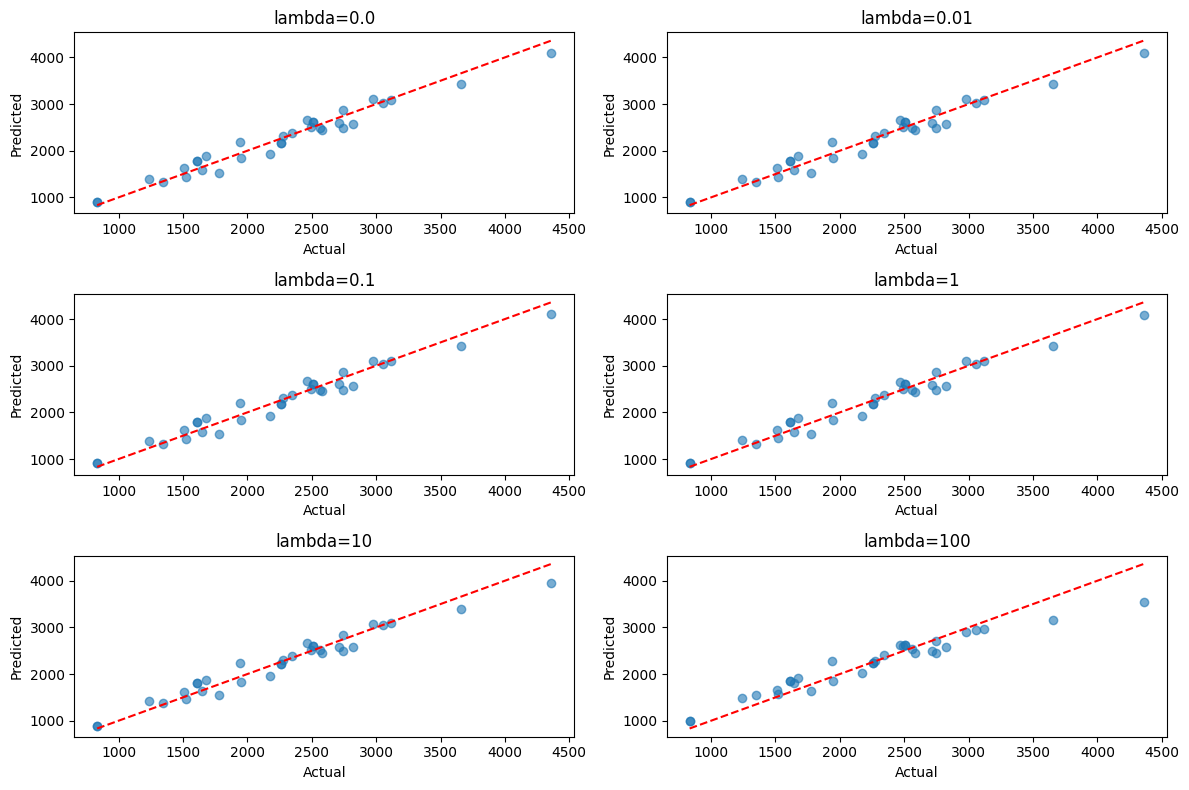

In [18]:
plt.figure(figsize=(12, 8))
for i, lam in enumerate(lambdas):
    theta = closed_form_ridge(X_train_scaled, y_train, lam=lam)
    y_pred = add_bias(X_test_scaled) @ theta
    plt.subplot(3, 2, i + 1)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'lambda={lam}')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
plt.tight_layout()
plt.show()



Top features by absolute weight (L2):


battery         167.764104
ram             162.837152
thickness       157.412005
internal mem    156.179290
ppi             152.088473
cpu core        121.328660
cpu freq         73.394720
weight           72.860199
resoloution      68.178626
Front_Cam        35.613308
Sale             31.663119
Product_id       21.155167
RearCam          18.459387
dtype: float64

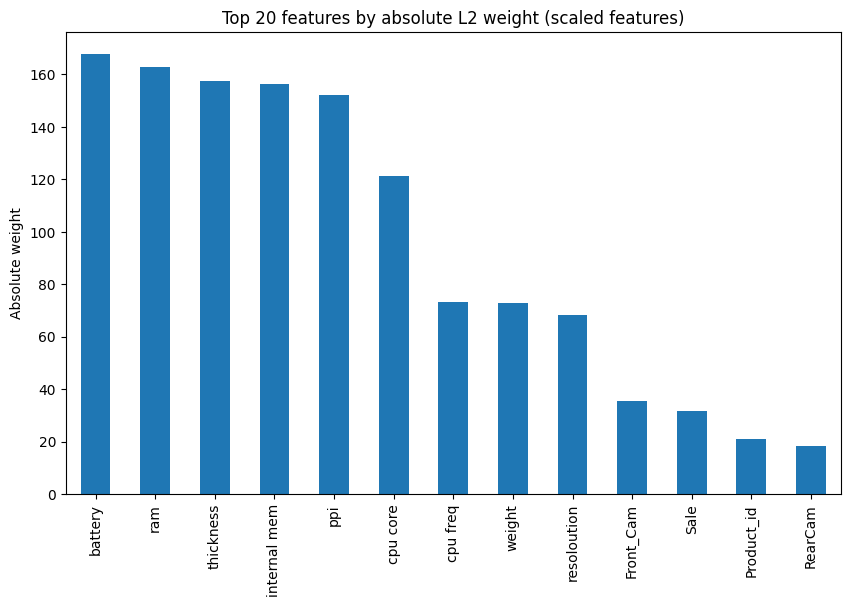

In [19]:
chosen_lam = 1.0
theta_scaled = closed_form_ridge(X_train_scaled, y_train, lam=chosen_lam)
# Exclude bias term
weights = theta_scaled[1:].flatten()

feature_names = df.drop(columns=[TARGET]).columns.tolist()
feat_imp = pd.Series(weights, index=feature_names)
feat_imp_sorted = feat_imp.abs().sort_values(ascending=False)

print('\nTop features by absolute weight (L2):')
display(feat_imp_sorted.head(20))

# Plot
plt.figure(figsize=(10, 6))
feat_imp_sorted.head(20).plot(kind='bar')
plt.title('Top 20 features by absolute L2 weight (scaled features)')
plt.ylabel('Absolute weight')
plt.show()

In [20]:
print('--- Summary ---')
print('Closed-form (no regularization) RMSE:', rmse(y_test, y_pred_closed))
print('GD (no regularization) RMSE:', rmse(y_test, y_pred_gd))
print('Ridge (lam={}) RMSE (closed):'.format(lam), rmse(y_test, y_pred_ridge_closed))
print('\nNotes:')
print('- Standardization often improves stability and performance when regularization is used.')
print('- Closed-form is fast for moderate-sized datasets but can be unstable when X^T X is near-singular; use pseudo-inverse or ridge.')
print('- Gradient descent is flexible and useful for very large datasets or streaming updates.')
print('- L2 weights magnitude (after scaling) offers a proxy for feature importance; interpret with caution.')

--- Summary ---
Closed-form (no regularization) RMSE: 151.8625361672479
GD (no regularization) RMSE: 287162.01687655406
Ridge (lam=100) RMSE (closed): 161.09202702770722

Notes:
- Standardization often improves stability and performance when regularization is used.
- Closed-form is fast for moderate-sized datasets but can be unstable when X^T X is near-singular; use pseudo-inverse or ridge.
- Gradient descent is flexible and useful for very large datasets or streaming updates.
- L2 weights magnitude (after scaling) offers a proxy for feature importance; interpret with caution.


# Question 2 :  Linear Classification

### Data Loading

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
np.random.seed(42)

In [26]:
DATA_PATH = '/kaggle/input/bank-note-authentication-uci-data/BankNote_Authentication.csv'


df = pd.read_csv(DATA_PATH, header=None)
if df.shape[1] == 5:
    df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']


print('Shape:', df.shape)
print(df.head())
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)
print(df.dtypes)

Shape: (1373, 5)
   variance  skewness  curtosis   entropy  class
0  variance  skewness  curtosis   entropy  class
1    3.6216    8.6661   -2.8073  -0.44699      0
2    4.5459    8.1674   -2.4586   -1.4621      0
3     3.866   -2.6383    1.9242   0.10645      0
4    3.4566    9.5228   -4.0112   -3.5944      0
variance    float64
skewness    float64
curtosis    float64
entropy     float64
class       float64
dtype: object


### EDA & Preprocessing


Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1372 entries, 1 to 1372
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   float64
dtypes: float64(5)
memory usage: 64.3 KB

Missing values per column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


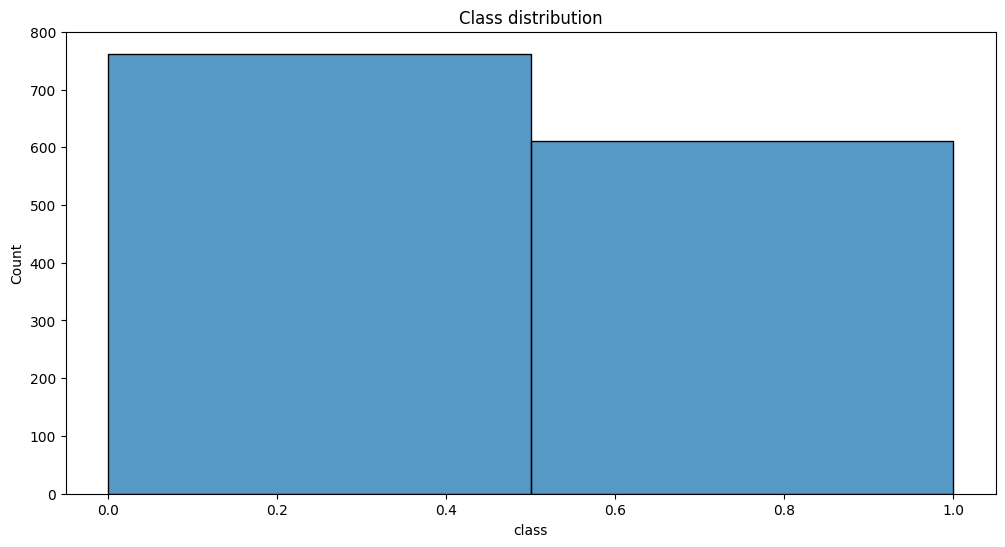

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

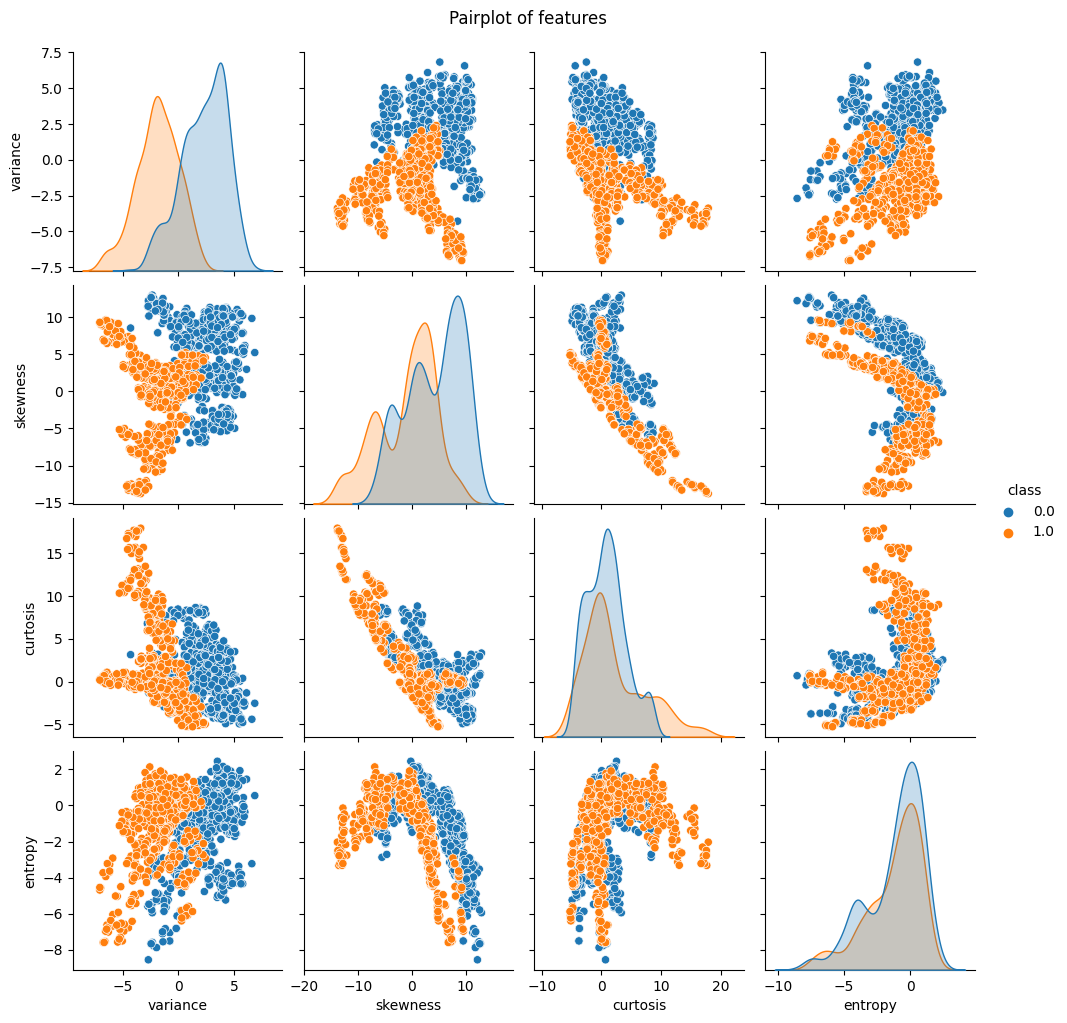

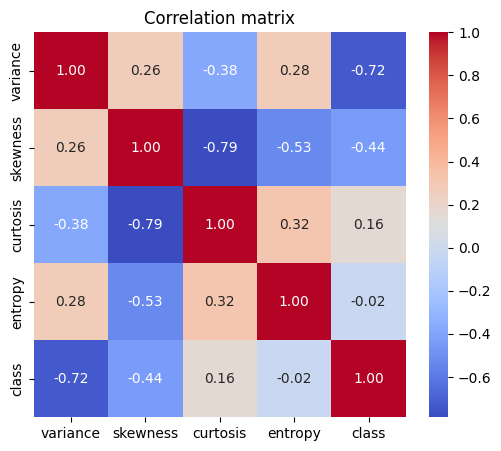

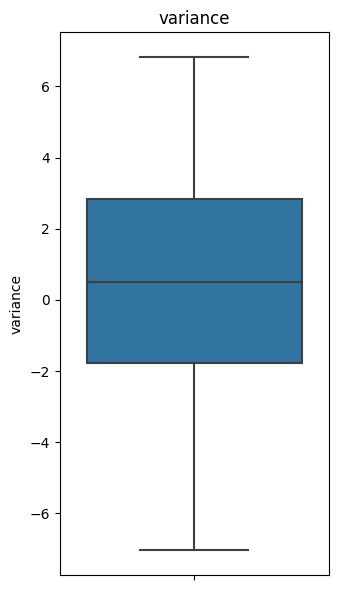

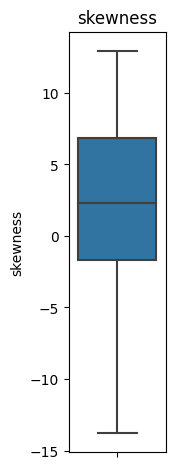

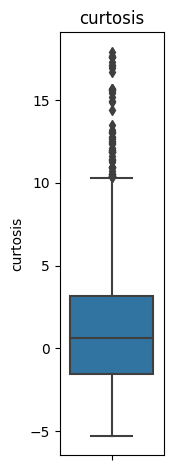

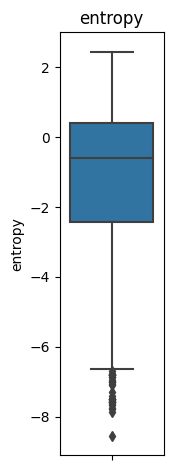

In [27]:
print('\nInfo:')
df.info()
print('\nMissing values per column:')
print(df.isna().sum())
display(df.describe().T)

plt.figure(figsize=(12,6))
sns.histplot(df['class'], bins=2)
plt.title('Class distribution')
plt.show()

# Pairplot 
sns.pairplot(df, hue='class', vars=['variance','skewness','curtosis','entropy'])
plt.suptitle('Pairplot of features', y=1.02)
plt.show()
# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()
# Boxplots to inspect outliers
plt.figure(figsize=(12,6))
for i, col in enumerate(['variance','skewness','curtosis','entropy']):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()

### Train Test Split

In [28]:
X = df.drop(columns=['class']).values
y = df['class'].values
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape: ', X_test.shape, y_test.shape)

# Standardize features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_orig = X_train_scaled.copy()
X_test_orig = X_test_scaled.copy()

Train shape: (1097, 4) (1097,)
Test shape:  (275, 4) (275,)


### Model Training and Evaluation

In [29]:
# Without regularization
clf_none = LogisticRegression(penalty='none', solver='saga', max_iter=5000, random_state=42)
clf_none.fit(X_train_scaled, y_train)
# With L2 regularization 
clf_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=5000, random_state=42)
clf_l2.fit(X_train_scaled, y_train)

y_train_pred_none = clf_none.predict(X_train_scaled)
y_test_pred_none = clf_none.predict(X_test_scaled)


y_train_pred_l2 = clf_l2.predict(X_train_scaled)
y_test_pred_l2 = clf_l2.predict(X_test_scaled)

print('No Regularization ')
print('Train acc:', accuracy_score(y_train, y_train_pred_none))
print('Test acc:', accuracy_score(y_test, y_test_pred_none))
print(classification_report(y_test, y_test_pred_none))


print('L2 Regularization (C=1.0)')
print('Train acc:', accuracy_score(y_train, y_train_pred_l2))
print('Test acc:', accuracy_score(y_test, y_test_pred_l2))
print(classification_report(y_test, y_test_pred_l2))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(


No Regularization 
Train acc: 0.9908842297174111
Test acc: 0.9854545454545455
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99       153
         1.0       0.97      1.00      0.98       122

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275

L2 Regularization (C=1.0)
Train acc: 0.9845031905195989
Test acc: 0.9709090909090909
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97       153
         1.0       0.94      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275



In [30]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', alpha=0.0001, max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

print('\nMLP (1 hidden layer)')
print('Train acc:', accuracy_score(y_train, mlp.predict(X_train_scaled)))
print('Test acc:', accuracy_score(y_test, mlp.predict(X_test_scaled)))
print(classification_report(y_test, mlp.predict(X_test_scaled)))


MLP (1 hidden layer)
Train acc: 1.0
Test acc: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       153
         1.0       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



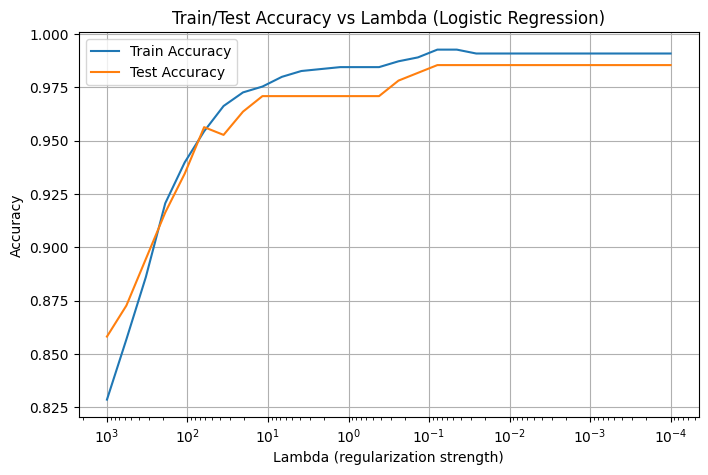

In [31]:
lambdas = np.logspace(-4, 3, 30) # from 1e-4 to 1e3
train_acc = []
test_acc = []
coefs = []
for lam in lambdas:
    C = 1.0 / lam if lam != 0 else 1e12
    clf = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=5000)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test_scaled)))
    coefs.append(clf.coef_.flatten())
# Plot accuracy vs lambda
plt.figure(figsize=(8,5))
plt.semilogx(lambdas, train_acc, label='Train Accuracy')
plt.semilogx(lambdas, test_acc, label='Test Accuracy')
plt.gca().invert_xaxis() # optional: show large C (low lambda) on left
plt.xlabel('Lambda (regularization strength)')
plt.ylabel('Accuracy')
plt.title('Train/Test Accuracy vs Lambda (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

Feature importance ranking (most important first):
skewness 4.808942316729346
variance 4.657893243647576
curtosis 4.3977195131303795
entropy 0.25516004111730867
Top 3 feature indices: [1 0 2]


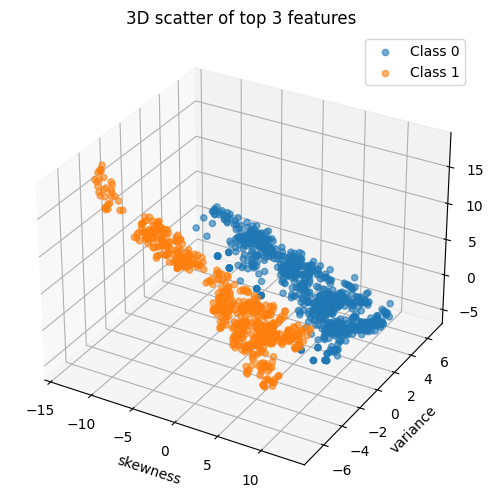

In [32]:
clf_for_imp = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=5000)
clf_for_imp.fit(X_train_scaled, y_train)
feat_importance = np.abs(clf_for_imp.coef_.flatten())
feat_names = ['variance','skewness','curtosis','entropy']
feat_ranking = np.argsort(feat_importance)[::-1]
print('Feature importance ranking (most important first):')
for idx in feat_ranking:
    print(feat_names[idx], feat_importance[idx])

# pick top 3 features
top3_idx = feat_ranking[:3]
print('Top 3 feature indices:', top3_idx)

# Use original (unscaled) data for interpretable 3D scatter
X_all = df.drop(columns=['class']).values
y_all = df['class'].values

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_all[y_all==0, top3_idx[0]], X_all[y_all==0, top3_idx[1]], X_all[y_all==0, top3_idx[2]], label='Class 0', alpha=0.6)
ax.scatter(X_all[y_all==1, top3_idx[0]], X_all[y_all==1, top3_idx[1]], X_all[y_all==1, top3_idx[2]], label='Class 1', alpha=0.6)
ax.set_xlabel(feat_names[top3_idx[0]])
ax.set_ylabel(feat_names[top3_idx[1]])
ax.set_zlabel(feat_names[top3_idx[2]])
ax.set_title('3D scatter of top 3 features')
ax.legend()
plt.show()

Injected 54 outliers into training data.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


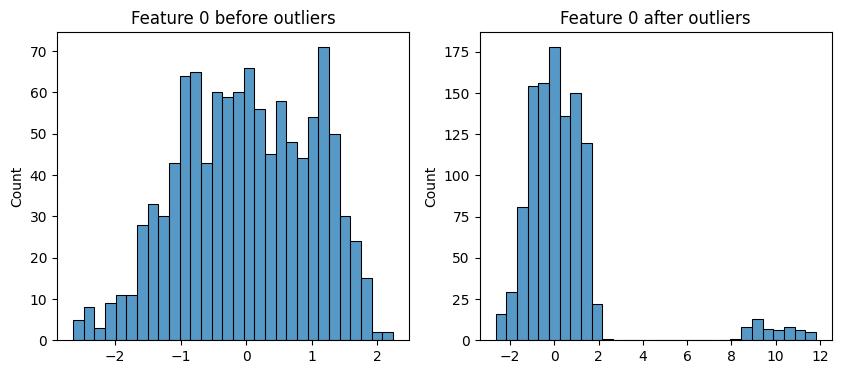

In [33]:
X_train_out = X_train_scaled.copy()
y_train_out = y_train.copy()

n_outliers = int(0.05 * X_train_out.shape[0]) # 5% of training samples
outlier_idx = np.random.choice(np.arange(X_train_out.shape[0]), size=n_outliers, replace=False)
shift_factors = np.array([10.0, 10.0, 10.0, 10.0]) # 10 std devs
X_train_out[outlier_idx] += shift_factors
print(f'Injected {n_outliers} outliers into training data.')
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(X_train_scaled[:,0], bins=30)
plt.title('Feature 0 before outliers')
plt.subplot(1,2,2)
sns.histplot(X_train_out[:,0], bins=30)
plt.title('Feature 0 after outliers')
plt.show()

In [34]:
clf_clean = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=5000)
clf_clean.fit(X_train_scaled, y_train)
clf_out = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=5000)
clf_out.fit(X_train_out, y_train_out := y_train.copy())

print('Clean-training model')
print('Train acc:', accuracy_score(y_train, clf_clean.predict(X_train_scaled)))
print('Test acc:', accuracy_score(y_test, clf_clean.predict(X_test_scaled)))

print('\nOutlier-injected training model')
print('Train acc (with outliers):', accuracy_score(y_train_out, clf_out.predict(X_train_out)))
print('Test acc (on original test set):', accuracy_score(y_test, clf_out.predict(X_test_scaled)))

print('\nConfusion matrix on test set (clean model):')
print(confusion_matrix(y_test, clf_clean.predict(X_test_scaled)))
print('\nConfusion matrix on test set (outlier model):')
print(confusion_matrix(y_test, clf_out.predict(X_test_scaled)))

# Print classification reports
print('\nClassification report (clean model):')
print(classification_report(y_test, clf_clean.predict(X_test_scaled)))
print('\nClassification report (outlier model):')
print(classification_report(y_test, clf_out.predict(X_test_scaled)))

Clean-training model
Train acc: 0.9845031905195989
Test acc: 0.9709090909090909

Outlier-injected training model
Train acc (with outliers): 0.8441203281677302
Test acc (on original test set): 0.8181818181818182

Confusion matrix on test set (clean model):
[[145   8]
 [  0 122]]

Confusion matrix on test set (outlier model):
[[124  29]
 [ 21 101]]

Classification report (clean model):
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97       153
         1.0       0.94      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275


Classification report (outlier model):
              precision    recall  f1-score   support

         0.0       0.86      0.81      0.83       153
         1.0       0.78      0.83      0.80       122

    accuracy                           0.82       275
   macro avg       0.82     

In [35]:
print('--- Summary ---')
print('- Logistic Regression performs well on this dataset with high accuracy.')
print('- L2 regularization can help generalization; tune lambda (plotted above).')
print('- A small neural network achieves comparable performance.')
print('- Injecting extreme outliers into the training set degrades model performance on the original test set and can cause the decision boundary to shift.')

--- Summary ---
- Logistic Regression performs well on this dataset with high accuracy.
- L2 regularization can help generalization; tune lambda (plotted above).
- A small neural network achieves comparable performance.
- Injecting extreme outliers into the training set degrades model performance on the original test set and can cause the decision boundary to shift.
